In [1]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers
# import bert
import pandas as pd
import re
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import BertTokenizer, TFBertModel,  BertConfig, BertTokenizerFast
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

# tensorflow.keras
from tensorflow.keras.layers import Input, Dropout, Dense, Embedding, LSTM, Flatten, Conv1D, MaxPooling1D, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.initializers import TruncatedNormal
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy
from tensorflow.keras.utils import to_categorical

In [3]:
# Import data from csv
data = pd.read_csv('datasetindo/20191002-reviews.csv')

In [4]:
# data.head()

,itemId,category,name,rating,originalRating,reviewTitle,reviewContent,likeCount,upVotes,downVotes,helpful,relevanceScore,boughtDate,clientType,retrievedDate
0,100002528,beli-harddisk-eksternal,Kamal U.,5,NaN,NaN,bagus mantap dah sesui pesanan,0,0,0,True,26.51,09 Apr 2019,androidApp,2019-10-02
1,100002528,beli-harddisk-eksternal,yofanca m.,4,NaN,NaN,"Bagus, sesuai foto",0,0,0,True,22.49,24 Sep 2017,androidApp,2019-10-02
2,100002528,beli-harddisk-eksternal,Lazada Customer,5,NaN,ok mantaaapppp barang sesuai pesanan.. good,okkkkk mantaaaaaaapppp ... goood,0,0,0,True,21.50,04 Apr 2018,androidApp,2019-10-02
3,100002528,beli-harddisk-eksternal,Lazada Customer,4,NaN,NaN,bagus sesuai,0,0,0,True,20.51,22 Sep 2017,androidApp,2019-10-02
4,100002528,beli-harddisk-eksternal,Yosep M.,5,NaN,NaN,NaN,0,0,0,True,16.01,17 Agu 2018,androidApp,2019-10-02


In [5]:
data = data[['reviewContent', 'rating']]

In [6]:
# data.head()

,reviewContent,rating
0,bagus mantap dah sesui pesanan,5
1,"Bagus, sesuai foto",4
2,okkkkk mantaaaaaaapppp ... goood,5
3,bagus sesuai,4
4,NaN,5


In [7]:
data = data.dropna()

In [8]:
ratingToLabel = lambda x: 1 if x>3 else 0
# Apply function to convert rating to label
data['rating'] = data['rating'].apply(ratingToLabel)

In [9]:
# data.head()

,reviewContent,rating
0,bagus mantap dah sesui pesanan,1
1,"Bagus, sesuai foto",1
2,okkkkk mantaaaaaaapppp ... goood,1
3,bagus sesuai,1
7,bima,0


In [10]:
# # Convert review coloumn to text
# dataReview['reviewContent'] = dataReview['reviewContent'].astype(str)

In [11]:
# Set your model output as categorical and save in new label col
data['rating_label'] = pd.Categorical(data['rating'])

In [12]:
# data.head()

,reviewContent,rating,rating_label
0,bagus mantap dah sesui pesanan,1,1
1,"Bagus, sesuai foto",1,1
2,okkkkk mantaaaaaaapppp ... goood,1,1
3,bagus sesuai,1,1
7,bima,0,0


In [13]:
data['rating'] = data['rating_label'].cat.codes

In [1]:
# data.info()

In [ ]:
def reduce_lengthening(text):
    pattern = re.compile(r"(.)\1{2,}")
    return pattern.sub(r"\1\1", text)

def remove_tags(text):
    TAG_RE = re.compile(r'<[^>]+>')
    return TAG_RE.sub('', text)

def preprocess_text(sen):
    # Removing html tags
    sentence = remove_tags(sen)
    
    #removing overlength word
    sentence = reduce_lengthening(sen)

    # Remove punctuations and numbers
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)

    # Single character removal
    sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)

    # Removing multiple spaces
    sentence = re.sub(r'\s+', ' ', sentence)

    return sentence

In [ ]:
data['reviewContent'] = data.reviewContent.apply(lambda x: preprocess_text(x))

In [15]:
# data, data_test = train_test_split(data, test_size = 0.2)
data, data_test = train_test_split(data, test_size=0.3, shuffle=True)

In [16]:
from transformers import BertTokenizer, TFBertModel

model_name='cahya/bert-base-indonesian-522M'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = TFBertModel.from_pretrained(model_name)
text = "Silakan diganti dengan text apa saja."
encoded_input = tokenizer(text, return_tensors='tf')
output = model(encoded_input)# Name of the BERT model to use
model_name = 'bert-base-uncased'

# Max length of tokens
max_length = 100

# Load transformers config and set output_hidden_states to False
config = BertConfig.from_pretrained(model_name)
config.output_hidden_states = False

# Load BERT tokenizer
tokenizer = BertTokenizerFast.from_pretrained(pretrained_model_name_or_path = model_name, config = config)

# Load the Transformers BERT model
transformer_model = TFBertModel.from_pretrained(model_name, config = config)

Some weights of the model checkpoint at bert-base-uncased were not used when initializing TFBertModel: ['nsp___cls', 'mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPretraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the model checkpoint at bert-base-uncased.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


In [17]:
# Load the MainLayer
bert = transformer_model.layers[0]

# Build your model input
input_ids = Input(shape=(max_length,), name='input_ids', dtype='int32')
# attention_mask = Input(shape=(max_length,), name='attention_mask', dtype='int32') 
# inputs = {'input_ids': input_ids, 'attention_mask': attention_mask}
inputs = {'input_ids': input_ids}

# Load the Transformers BERT model as a layer in a Keras model
bert_model = bert(inputs)[1]
dropout = Dropout(config.hidden_dropout_prob, name='pooled_output')
pooled_output = dropout(bert_model, training=False)

# Then build your model output
issue = Dense(units=len(data.rating_label.value_counts()), kernel_initializer=TruncatedNormal(stddev=config.initializer_range), name='issue')(pooled_output)
# product = Dense(units=len(data.Product_label.value_counts()), kernel_initializer=TruncatedNormal(stddev=config.initializer_range), name='product')(pooled_output)
outputs = {'issue': issue}

# And combine it all in a model object
model = Model(inputs=inputs, outputs=outputs, name='BERT_MultiLabel_MultiClass')

# Take a look at the model
# model.summary()

Model: "BERT_MultiLabel_MultiClass"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_ids (InputLayer)       [(None, 100)]             0         
_________________________________________________________________
bert (TFBertMainLayer)       ((None, 100, 768), (None, 109482240 
_________________________________________________________________
pooled_output (Dropout)      (None, 768)               0         
_________________________________________________________________
issue (Dense)                (None, 2)                 1538      
Total params: 109,483,778
Trainable params: 109,483,778
Non-trainable params: 0
_________________________________________________________________


In [18]:
# Set an optimizer
optimizer = Adam(
    learning_rate=5e-05,
    epsilon=1e-08,
    decay=0.01,
    clipnorm=1.0)

# Set loss and metrics
loss = {'issue': CategoricalCrossentropy(from_logits = True)}
metric = {'issue': CategoricalAccuracy('accuracy')}

# Compile the model
model.compile(
    optimizer = optimizer,
    loss = loss, 
    metrics = metric)

In [21]:
# Ready output data for the model
y_issue = to_categorical(data['rating'])

# Ready test data
test_y_issue = to_categorical(data_test['rating'])

# Tokenize the input
x = tokenizer(
    text=data['reviewContent'].to_list(),
    add_special_tokens=True,
    max_length=max_length,
    truncation=True,
    padding=True, 
    return_tensors='tf',
    return_token_type_ids = False,
    return_attention_mask = True,
    verbose = True)

test_x = tokenizer(
    text=data_test['reviewContent'].to_list(),
    add_special_tokens=True,
    max_length=max_length,
    truncation=True,
    padding=True, 
    return_tensors='tf',
    return_token_type_ids = False,
    return_attention_mask = False,
    verbose = True)


In [22]:
# Fit the model NEW
csv_logger = tf.keras.callbacks.CSVLogger('modelBERT2TrainingNEW.csv')
history = model.fit(
    x={'input_ids': x['input_ids']},
    y={'issue': y_issue}, callbacks=[csv_logger],
    validation_data=({'input_ids': test_x['input_ids']},test_y_issue), batch_size=16, epochs=5, verbose=1)

Epoch 1/5
4683/4683 [==============================] - 1177s 251ms/step - loss: 0.2347 - accuracy: 0.9066 - val_loss: 0.1957 - val_accuracy: 0.9238
Epoch 2/5
4683/4683 [==============================] - 1174s 251ms/step - loss: 0.1951 - accuracy: 0.9259 - val_loss: 0.1883 - val_accuracy: 0.9279
Epoch 3/5
4683/4683 [==============================] - 1174s 251ms/step - loss: 0.1855 - accuracy: 0.9297 - val_loss: 0.1852 - val_accuracy: 0.9301
Epoch 4/5
4683/4683 [==============================] - 1175s 251ms/step - loss: 0.1807 - accuracy: 0.9321 - val_loss: 0.1775 - val_accuracy: 0.9337
Epoch 5/5
4683/4683 [==============================] - 1172s 250ms/step - loss: 0.1762 - accuracy: 0.9342 - val_loss: 0.1754 - val_accuracy: 0.9344


In [23]:
model.save('Model/BERTmodel1.h5')

In [35]:
# # Run evaluation
# model_eval = model.evaluate(
#     x={'input_ids': test_x['input_ids']},
#     y={'issue': test_y_issue}
# )

669/669 [==============================] - 92s 137ms/step - loss: 0.2955 - accuracy: 0.8951


In [25]:
ypred = model.predict(x={'input_ids': test_x['input_ids']}, verbose=1)

1004/1004 [==============================] - 134s 134ms/step


In [26]:
y_pred = np.argmax(ypred['issue'], axis=1) 

In [27]:
#Plotting COnfusion Matrix
def plot_confusion_matrix(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=True):

    import itertools
    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")


    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label\naccuracy={:0.4f}; misclass={:0.4f}'.format(accuracy, misclass))
    plt.show()

In [28]:
Y_Train =  data['rating'].values
Y_Test = data_test['rating'].values

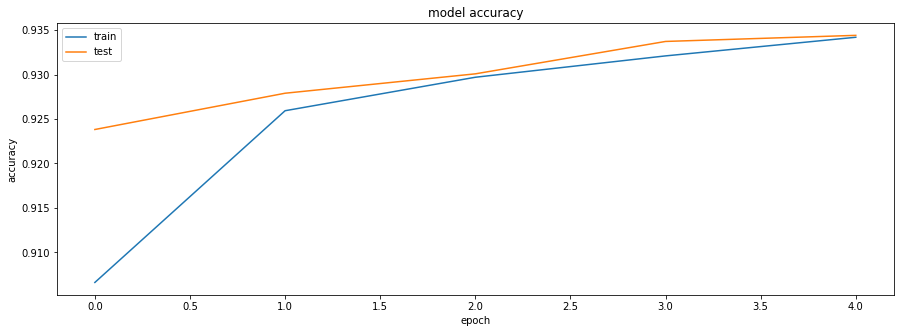

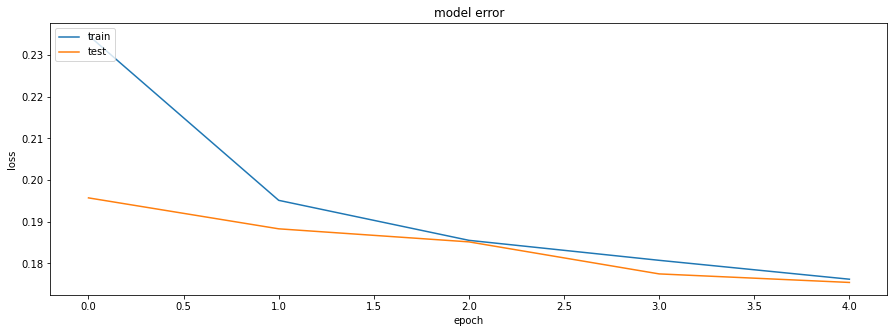

[[ 2645  1343]
 [  763 27358]]
              precision    recall  f1-score   support

    Negative       0.78      0.66      0.72      3988
    Positive       0.95      0.97      0.96     28121

    accuracy                           0.93     32109
   macro avg       0.86      0.82      0.84     32109
weighted avg       0.93      0.93      0.93     32109



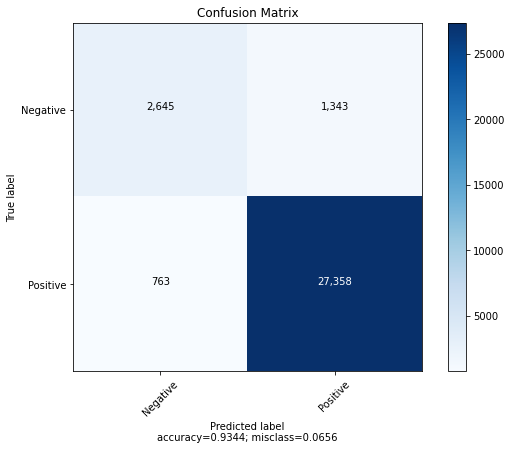

In [29]:
# Model4 BERT

plt.figure(figsize=(15,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

plt.figure(figsize=(15,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model error')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

yTrue = Y_Test.tolist()
target_names = ['Negative', 'Positive']
print(confusion_matrix(yTrue, y_pred))
print(classification_report(yTrue, y_pred, target_names=target_names))

plot_confusion_matrix(cm           = confusion_matrix(yTrue, y_pred), 
                      normalize    = False,
                      target_names = target_names,
                      title        = "Confusion Matrix")


In [ ]:
print('Training Finished!')